In [1]:
!pip install matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_info_columns', 100)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

## Week 1 – Monthly Dataset Aggregation
sold1 = pd.read_csv('CRMLSSold202401.csv')
sold2 = pd.read_csv('CRMLSSold202402.csv') 
sold = pd.concat([sold1, sold2])

#Outputs: 

  Combined sold transactions dataset 
  Combined listing data dataset 

#Skills Learned:

  Multi-file dataset management 
  Data aggregation with Pandas 
  Preparing time-series datasets for analysis 

In [3]:
# combine data
print("Loading Listed Data...")
#### ?
dtype_dict = {
    'ListAgentEmail': str,
    'BuyerAgencyCompensationType': str,
    'BuyerAgentAOR': str,
    'OriginatingSystemName': str,
    'latfilled': float,
    'lonfilled': float
}
listed_files = glob.glob('CRMLSListing*.csv')
df_listed = pd.concat((pd.read_csv(f, encoding='latin1') for f in listed_files), ignore_index=True)
#df_listed = pd.concat((pd.read_csv(f) for f in listed_files), ignore_index=True)

print("Loading Sold Data...")
sold_files = glob.glob('CRMLSSold*.csv')
df_sold = pd.concat((pd.read_csv(f, encoding='latin1') for f in sold_files), ignore_index=True)
#df_sold = pd.concat((pd.read_csv(f, low_memory=False) for f in sold_files), ignore_index=True)
print("Data loaded successfully!")

Loading Listed Data...
Loading Sold Data...


C:\Users\wzy\AppData\Local\Temp\ipykernel_56076\1176271889.py:18: DtypeWarning: Columns (0: WaterfrontYN, 1: ElementarySchool, 2: BuilderName, 3: CoBuyerAgentFirstName, 4: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.concat((pd.read_csv(f, encoding='latin1') for f in sold_files), ignore_index=True)
C:\Users\wzy\AppData\Local\Temp\ipykernel_56076\1176271889.py:18: DtypeWarning: Columns (0: WaterfrontYN) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.concat((pd.read_csv(f, encoding='latin1') for f in sold_files), ignore_index=True)
C:\Users\wzy\AppData\Local\Temp\ipykernel_56076\1176271889.py:18: DtypeWarning: Columns (0: WaterfrontYN, 1: PostalCode) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.concat((pd.read_csv(f, encoding='latin1') for f in sold_files), ignore_index=True)


Data loaded successfully!


In [4]:
print(f"listing:{df_listed.shape}")
print(f"sold:{df_sold.shape}")

listing:(893091, 84)
sold:(615591, 84)


In [5]:
# check head
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_listed.head(3))
    display(df_sold.head(3))

,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,PropertyType.1,MlsStatus,ElementarySchool,ListAgentFirstName.1,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,DaysOnMarket.1,BuyerAgencyCompensationType,StreetNumberNumeric,LivingArea.1,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,Longitude.1,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,Latitude.1,ListPrice.1,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,ListAgentLastName.1,CloseDate.1,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,90000.0,1075010398,miriamlara03@gmail.com,NaN,NaN,Miriam,Lara,34.097939,-117.909653,1045 N Azusa 61,ManufacturedInPark,960.0,90000.0,0,CENTURY 21 CITRUS REALTY INC,NaN,NaN,Miriam Lara,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1075010398,614 - Covina,NaN,Los Angeles,ManufacturedInPark,Active,NaN,Miriam,False,4.0,NaN,NaN,NaN,NaN,NaN,1960.0,0,Item,1045.0,960.0,CV24093347,1.0,Covina,2500.0,NaN,NaN,4.0,2024-01-29,-117.909653,NaN,NaN,NaN,2024-01-29,NaN,NaN,34.097939,90000.0,CA,NaN,NaN,NaN,1.0,NaN,One,Lara,NaN,NaN,NaN,NaN,NaN,2.0,Covina Valley Unified,91722,NaN,0.0,NaN,NaN,1045 N Azusa 61
1,1500000.0,1074974457,janelle@judsonre.com,NaN,NaN,Janelle,Judson,33.121241,-117.081614,NaN,CommercialSale,NaN,1500000.0,0,Judson Real Estate,NaN,Judson Real Estate,Janelle Judson,Lynn,Judson,NaN,NaN,NaN,NaN,NaN,NaN,1074974457,92025 - Escondido,NaN,San Diego,CommercialSale,Active,NaN,Janelle,NaN,0.0,NaN,Retail,NaN,NaN,NaN,1940.0,0,Item1,NaN,NaN,NDP2403932,0.0,Escondido,2.0,NaN,3000.0,NaN,2024-01-11,-117.081614,NaN,NaN,NaN,2024-01-11,NaN,NaN,33.121241,1500000.0,CA,NaN,NaN,NaN,NaN,NaN,NaN,Judson,NaN,NaN,3052.0,NaN,NaN,NaN,NaN,92025,NaN,0.0,NaN,NaN,NaN
2,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,Residential,1301.0,1340000.0,127,Rodeo Realty- Brentwood,NaN,NaN,Haleh Dowlatshahi,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,NaN,1074973329,C05 - Westwood - Century City,NaN,Los Angeles,Residential,Pending,NaN,Haleh,NaN,0.0,NaN,Condominium,4.0831,NaN,NaN,1964.0,127,Item1,2220.0,1301.0,24389291,2.0,Los Angeles,2.0,NaN,1301.0,2.0,2024-05-07,-118.408445,NaN,NaN,2024-05-07,2024-01-01,NaN,NaN,34.052207,1340000.0,CA,NaN,NaN,False,1.0,NaN,One,Dowlatshahi,NaN,NaN,177861.0,NaN,False,NaN,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,Joan,Wachter,NaN,NaN,1 Baldwin Avenue 411,Residential,1140.0,295000.0,777,Coldwell Banker Realty,Bay Area Senior Services,NaN,Joan Wachter,NaN,NaN,ML5090968,Scott,Withrow,NaN,Monthly,NaN,551985747,699 - Not Defined,NaN,San Mateo,Closed,NaN,False,1.0,NaN,Condominium,NaN,NaN,Mlslistings,1988.0,1.0,ML81865679,2.0,San Mateo,NaN,NaN,2.0,2024-01-26,NaN,NaN,2023-11-22,2021-10-06,NaN,NaN,CA,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,Other,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN
1,HighDesert,HighDesert,NaN,NaN,NaN,NaN,NaN,0.0,535486633,eabrown@lee-associates.com,2024-01-24,950.0,Elizabeth,Brown,34.529407,-117.319674,15770 Mojave Drive L,CommercialLease,NaN,808.0,901,Lee & Associates,Lee & Associates,NaN,Elizabeth Brown,NaN,NaN,HD11042,Elizabeth,Brown,NaN,NaN,NaN,535486633,NaN,NaN,San Bernardino,Closed,NaN,NaN,NaN,NaN,Retail,1.20,NaN,HighDesert,1980.0,15770.0,538013,NaN,Victorville,NaN,NaN,NaN,2024-01-24,NaN,NaN,2024-01-24,2021-08-06,NaN,Other,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52320.0,NaN,NaN,NaN,NaN,92394,NaN,52320.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN
2,OrangeCounty,OrangeCounty,NaN,True,NaN,NaN,NaN,75000.0,529986282,Joe@9WINWIN.com,2024-01-16,45000.0,Joseph,Piteleski,35.618009,-118.473141,0 Shadow mountain Dr.,Land,NaN,75000.0,865,Keller Williams OC Coastal Realty,Keller Williams OC Coastal Realty,NaN,Joseph Piteleski,NaN,NaN,spitejos,Joseph,Piteleski,NaN,NaN,NaN,529986282,LKIS - Lake Isabella,NaN,Kern,Closed,NaN,NaN,NaN,NaN,NaN,4.99,NaN,OrangeCounty,NaN,0.0,OC21157144,NaN,Lake Isabella,NaN,NaN,NaN,2024-01-16,NaN,NaN,2023-12-22,2021-07-18,NaN,NaN,CA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,217364.0,NaN,False,NaN,NaN,93240,NaN,217364.0,NaN,CRMLS,CRMLS_CRM,NaN,NaN,NaN,NaN


In [6]:
print(f"Listed row count before filtering: {len(df_listed)}")
print(f"Sold row count before filtering: {len(df_sold)}")

# Filter for Residential properties
print("Filtering for Residential properties...\n")

# Print to check available property types in the raw data
print("Original PropertyTypes in Listed Data:", df_listed['PropertyType'].unique())
print("Original PropertyTypes in Sold Data:", df_sold['PropertyType'].unique())
print("\n")
# Execute the filter (case-insensitive, handles NaN values)
#df_listed = df_listed[df_listed['PropertyType'].str.contains('Residential', case=False, na=False)]
#df_sold = df_sold[df_sold['PropertyType'].str.contains('Residential', case=False, na=False)]
df_listed = df_listed[df_listed['PropertyType']=='Residential']
df_sold = df_sold[df_sold['PropertyType']=='Residential']

print(f"Listed row count after filtering: {len(df_listed)}")
print(f"Sold row count after filtering: {len(df_sold)}")
print("\n")
print("Filtered PropertyTypes in Listed Data:", df_listed['PropertyType'].unique())
print("Filtered PropertyTypes in Sold Data:", df_sold['PropertyType'].unique())
print("\n")
df_listed.to_csv('Week1_Filtered_Listed.csv', index=False)
df_sold.to_csv('Week1_Filtered_Sold.csv', index=False)

Listed row count before filtering: 893091
Sold row count before filtering: 615591
Filtering for Residential properties...

Original PropertyTypes in Listed Data: <StringArray>
[ 'ManufacturedInPark',      'CommercialSale',         'Residential',
    'ResidentialLease',                'Land',   'ResidentialIncome',
     'CommercialLease', 'BusinessOpportunity']
Length: 8, dtype: str
Original PropertyTypes in Sold Data: <StringArray>
[        'Residential',     'CommercialLease',                'Land',
    'ResidentialLease',  'ManufacturedInPark',   'ResidentialIncome',
      'CommercialSale', 'BusinessOpportunity']
Length: 8, dtype: str


Listed row count after filtering: 567266
Sold row count after filtering: 413951


Filtered PropertyTypes in Listed Data: <StringArray>
['Residential']
Length: 1, dtype: str
Filtered PropertyTypes in Sold Data: <StringArray>
['Residential']
Length: 1, dtype: str




### Summary - Deliverable – Week 1 
Submit a .py script that concatenates all monthly files from January 2024 through the most recently 
completed calendar month into two combined datasets (listings and sold), filters both to PropertyType == 
‘Residential’ only, and saves them as new CSVs. Include comments confirming row counts before and 
after concatenation and before and after the Residential filter. 

## Weeks 2–3 – Dataset Structuring and Validation

### Dataset Understanding 
• Identify number of rows and columns

• Review column data types 

• Identify high-missing columns 

• Separate market analysis fields from metadata fields 

In [7]:
# Review
df_listed = pd.read_csv('Week1_Filtered_Listed.csv')
df_sold = pd.read_csv('Week1_Filtered_Sold.csv')

with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_listed.head(1))
    display(df_sold.head(1))


C:\Users\wzy\AppData\Local\Temp\ipykernel_56076\640228974.py:2: DtypeWarning: Columns (0: ListAgentEmail, 1: BuyerAgencyCompensationType) have mixed types. Specify dtype option on import or set low_memory=False.
  df_listed = pd.read_csv('Week1_Filtered_Listed.csv')
C:\Users\wzy\AppData\Local\Temp\ipykernel_56076\640228974.py:3: DtypeWarning: Columns (0: BuyerAgentAOR, 1: ListAgentAOR, 2: ListAgentEmail, 3: FireplaceYN, 4: OriginatingSystemName, 5: OriginatingSystemSubName, 6: BuyerAgencyCompensationType, 7: latfilled, 8: lonfilled) have mixed types. Specify dtype option on import or set low_memory=False.
  df_sold = pd.read_csv('Week1_Filtered_Sold.csv')


,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,PropertyType.1,MlsStatus,ElementarySchool,ListAgentFirstName.1,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,DaysOnMarket.1,BuyerAgencyCompensationType,StreetNumberNumeric,LivingArea.1,ListingId,BathroomsTotalInteger,City,BuyerAgencyCompensation,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,Longitude.1,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,Latitude.1,ListPrice.1,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,ListAgentLastName.1,CloseDate.1,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,UnparsedAddress.1
0,1340000.0,1074973329,haleh360@Gmail.com,NaN,NaN,Haleh,Dowlatshahi,34.052207,-118.408445,2220 Avenue Of The Stars 2704,Residential,1301.0,1340000.0,127,Rodeo Realty- Brentwood,NaN,NaN,Haleh Dowlatshahi,NaN,NaN,NaN,NaN,NaN,NaN,Monthly,NaN,1074973329,C05 - Westwood - Century City,NaN,Los Angeles,Residential,Pending,NaN,Haleh,NaN,0.0,NaN,Condominium,4.0831,NaN,NaN,1964.0,127,Item1,2220.0,1301.0,24389291,2.0,Los Angeles,2.0,NaN,1301.0,2.0,2024-05-07,-118.408445,NaN,NaN,2024-05-07,2024-01-01,NaN,NaN,34.052207,1340000.0,CA,NaN,NaN,False,1.0,NaN,One,Dowlatshahi,NaN,NaN,177861.0,NaN,False,NaN,NaN,90067,NaN,2105.0,177861.0,NaN,2220 Avenue Of The Stars 2704


,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,LivingArea,ListPrice,DaysOnMarket,ListOfficeName,BuyerOfficeName,CoListOfficeName,ListAgentFullName,CoListAgentFirstName,CoListAgentLastName,BuyerAgentMlsId,BuyerAgentFirstName,BuyerAgentLastName,FireplacesTotal,AssociationFeeFrequency,AboveGradeFinishedArea,ListingKeyNumeric,MLSAreaMajor,TaxAnnualAmount,CountyOrParish,MlsStatus,ElementarySchool,AttachedGarageYN,ParkingTotal,BuilderName,PropertySubType,LotSizeAcres,SubdivisionName,BuyerOfficeAOR,YearBuilt,StreetNumberNumeric,ListingId,BathroomsTotalInteger,City,TaxYear,BuildingAreaTotal,BedroomsTotal,ContractStatusChangeDate,ElementarySchoolDistrict,CoBuyerAgentFirstName,PurchaseContractDate,ListingContractDate,BelowGradeFinishedArea,BusinessType,StateOrProvince,CoveredSpaces,MiddleOrJuniorSchool,FireplaceYN,Stories,HighSchool,Levels,LotSizeDimensions,LotSizeArea,MainLevelBedrooms,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,OriginatingSystemName,OriginatingSystemSubName,BuyerAgencyCompensationType,BuyerAgencyCompensation,latfilled,lonfilled
0,Mlslistings,Mlslistings,"Carpet,Tile,Wood",True,NaN,NaN,False,499000.0,551985747,jwachter@cbnorcal.com,2024-01-26,240000.0,Joan,Wachter,NaN,NaN,1 Baldwin Avenue 411,Residential,1140.0,295000.0,777,Coldwell Banker Realty,Bay Area Senior Services,NaN,Joan Wachter,NaN,NaN,ML5090968,Scott,Withrow,NaN,Monthly,NaN,551985747,699 - Not Defined,NaN,San Mateo,Closed,NaN,False,1.0,NaN,Condominium,NaN,NaN,Mlslistings,1988.0,1.0,ML81865679,2.0,San Mateo,NaN,NaN,2.0,2024-01-26,NaN,NaN,2023-11-22,2021-10-06,NaN,NaN,CA,NaN,NaN,True,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,Other,94401,6472.0,NaN,NaN,CRMLS,CRMLS_MLSL,NaN,NaN,NaN,NaN


In [8]:
print(f"Listed rows and columns: {df_listed.shape}")
df_listed.info()

Listed rows and columns: (567266, 84)
<class 'pandas.DataFrame'>
RangeIndex: 567266 entries, 0 to 567265
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   OriginalListPrice             566458 non-null  float64
 1   ListingKey                    567266 non-null  int64  
 2   ListAgentEmail                519638 non-null  str    
 3   CloseDate                     164047 non-null  str    
 4   ClosePrice                    142156 non-null  float64
 5   ListAgentFirstName            562795 non-null  str    
 6   ListAgentLastName             567225 non-null  str    
 7   Latitude                      486803 non-null  float64
 8   Longitude                     486803 non-null  float64
 9   UnparsedAddress               566456 non-null  str    
 10  PropertyType                  567266 non-null  str    
 11  LivingArea                    566687 non-null  float64
 12  ListPrice        

In [9]:
print(f"Sold rows and columns: {df_sold.shape}")
df_sold.info() 

Sold rows and columns: (413951, 84)
<class 'pandas.DataFrame'>
RangeIndex: 413951 entries, 0 to 413950
Data columns (total 84 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   BuyerAgentAOR                 363072 non-null  str    
 1   ListAgentAOR                  367762 non-null  str    
 2   Flooring                      265403 non-null  str    
 3   ViewYN                        378704 non-null  object 
 4   WaterfrontYN                  259 non-null     object 
 5   BasementYN                    8099 non-null    object 
 6   PoolPrivateYN                 378289 non-null  object 
 7   OriginalListPrice             413196 non-null  float64
 8   ListingKey                    413951 non-null  int64  
 9   ListAgentEmail                385137 non-null  str    
 10  CloseDate                     413951 non-null  str    
 11  ClosePrice                    413949 non-null  float64
 12  ListAgentFirstName 

#### Missing Value Analysis 
• Calculate missing counts and percentages per column

• Flag columns with >90% missing values 

• Decide which columns to drop vs. retain (keep core fields even if partially missing) 

In [10]:
# Week 2 EDA Validation Report
#df_listed = df_listed.drop_duplicates(subset=None, keep='first')

# Flag columns with >90% missing values
def check_missing(df, name):
    core_keys = [
        'ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 
        'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 
        'DaysOnMarket', 'YearBuilt'
    ]

    # check invalid
    print(f"*************** {name} Data Missing Values ***************")
    display(df.isnull().sum().sort_values(ascending=False).head(20))
    #print(df_sold.isnull().sum().sort_values(ascending=False))

    missing_counts = df.isnull().sum()
    missing_pct = (missing_counts/len(df) * 100).round(2)
    missing_df = pd.DataFrame({
        'Null Count': missing_counts,
        'Null %': missing_pct
    }).sort_values(by='Null %', ascending=False)
    print(f"Columns rank by missing values in {name} Data ---")
    display(missing_df.head(20))
    
    high_missing = missing_df[missing_df['Null %'] > 90]
    print(f"Columns with over 90% missing values in {name} Data ---")
    display(high_missing)
    high_missing_cols = high_missing.index.tolist()
    
    # Drop them except core keys
    cols_to_drop = [col for col in high_missing_cols if col not in core_keys]
    df_drop = df.drop(columns=cols_to_drop)
    print(f"Automatically dropped {len(cols_to_drop)} columns with > 90% missing data.")
    print(f"shape: {df_drop.shape}\n")
    return df_drop
    

df_listed_c=check_missing(df_listed, "Listed")
df_sold_c=check_missing(df_sold, "Sold")

*************** Listed Data Missing Values ***************


TaxYear                         567266
TaxAnnualAmount                 567266
AboveGradeFinishedArea          567266
FireplacesTotal                 567266
ElementarySchoolDistrict        567266
BusinessType                    567266
CoveredSpaces                   567266
MiddleOrJuniorSchoolDistrict    567266
BelowGradeFinishedArea          564051
CoBuyerAgentFirstName           553092
BuilderName                     540937
LotSizeDimensions               537601
BuildingAreaTotal               516693
ElementarySchool                499687
MiddleOrJuniorSchool            499627
BuyerAgencyCompensation         488273
BuyerAgencyCompensationType     488253
HighSchool                      478609
CoListAgentFirstName            440634
CoListAgentLastName             440216
dtype: int64

Columns rank by missing values in Listed Data ---


,Null Count,Null %
TaxYear,567266,100.00
TaxAnnualAmount,567266,100.00
AboveGradeFinishedArea,567266,100.00
FireplacesTotal,567266,100.00
ElementarySchoolDistrict,567266,100.00
BusinessType,567266,100.00
CoveredSpaces,567266,100.00
MiddleOrJuniorSchoolDistrict,567266,100.00
BelowGradeFinishedArea,564051,99.43
CoBuyerAgentFirstName,553092,97.50


Columns with over 90% missing values in Listed Data ---


...

Columns rank by missing values in Sold Data ---


,Null Count,Null %
TaxYear,413951,100.00
FireplacesTotal,413951,100.00
TaxAnnualAmount,413951,100.00
AboveGradeFinishedArea,413951,100.00
ElementarySchoolDistrict,413951,100.00
BusinessType,413951,100.00
CoveredSpaces,413951,100.00
MiddleOrJuniorSchoolDistrict,413951,100.00
WaterfrontYN,413692,99.94
BelowGradeFinishedArea,411548,99.42


Columns with over 90% missing values in Sold Data ---


,Null Count,Null %
TaxYear,413951,100.00
FireplacesTotal,413951,100.00
TaxAnnualAmount,413951,100.00
AboveGradeFinishedArea,413951,100.00
ElementarySchoolDistrict,413951,100.00
BusinessType,413951,100.00
CoveredSpaces,413951,100.00
MiddleOrJuniorSchoolDistrict,413951,100.00
WaterfrontYN,413692,99.94
BelowGradeFinishedArea,411548,99.42


Automatically dropped 15 columns with > 90% missing data.
shape: (413951, 69)



#### Numeric Distribution Review 
Analyze the distribution of key numeric fields: ClosePrice, ListPrice, OriginalListPrice, LivingArea, 
LotSizeAcres, BedroomsTotal, BathroomsTotalInteger, DaysOnMarket, and YearBuilt. For each field, 
generate histograms, boxplots, and percentile summaries, and identify extreme outliers for later handling.

In [11]:
df_listed = df_listed_c
df_sold = df_sold_c

# Core numerical distribution report (min, max, mean, median, percentiles)
core_metrics = ['ClosePrice', 'LivingArea', 'DaysOnMarket']
print("\n--- Core Numerical Distribution for Sold Data (EDA Report Material) ---")

# describe(percentiles=[...]) automatically calculates all required values
#display(df_sold[core_metrics].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).apply(lambda s: s.apply('{0:.2f}'.format)))

# Drop empty columns

# transfer date
df_listed['ListingContractDate'] = pd.to_datetime(df_listed['ListingContractDate'], errors='coerce')
df_sold['CloseDate'] = pd.to_datetime(df_sold['CloseDate'], errors='coerce')
df_sold['ListingContractDate'] = pd.to_datetime(df_sold['ListingContractDate'], errors='coerce')

# transfer value
numeric_cols_listed = ['OriginalListPrice', 'ListPrice', 'LivingArea', 'DaysOnMarket', 'BedroomsTotal', 'BathroomsTotalInteger']
for col in numeric_cols_listed:
    df_listed[col] = pd.to_numeric(df_listed[col], errors='coerce')

numeric_cols_sold = ['ClosePrice', 'ListPrice', 'LivingArea', 'DaysOnMarket', 'BedroomsTotal', 'BathroomsTotalInteger']
for col in numeric_cols_sold:
    df_sold[col] = pd.to_numeric(df_sold[col], errors='coerce')
    
print("Data types converted.")


--- Core Numerical Distribution for Sold Data (EDA Report Material) ---
Data types converted.


## Deliverable – Weeks 2
Submit a .py script documenting unique property types found, the filtering logic applied, and a null-count 
summary table. Include a missing value report flagging any columns above 90% null. Produce a numeric 
distribution summary (min, max, mean, median, percentiles) for ClosePrice, LivingArea, and 
DaysOnMarket. Save the filtered dataset as a new CSV. 

In [12]:
# clean duplicate
#df_sold = df_sold.drop_duplicates(subset=['ListingKey'], keep='last')

# Filter outliers (only on sold data)
df_sold = df_sold[df_sold['ClosePrice'] > 10000]
df_sold = df_sold[df_sold['LivingArea'] > 100]

# Fill missing values
df_listed['DaysOnMarket'] = df_listed['DaysOnMarket'].fillna(df_listed['DaysOnMarket'].median())
df_listed['PropertyType'] = df_listed['PropertyType'].fillna('Unknown')

df_sold['DaysOnMarket'] = df_sold['DaysOnMarket'].fillna(df_sold['DaysOnMarket'].median())
df_sold['PropertyType'] = df_sold['PropertyType'].fillna('Unknown')

print(f"Cleaned Sold rows: {len(df_sold)}")

Cleaned Sold rows: 413494


In [13]:
# Listed features
df_listed['PricePerSqFt'] = df_listed['ListPrice'] / df_listed['LivingArea']
df_listed['PricePerSqFt'] = df_listed['PricePerSqFt'].replace([np.inf, -np.inf], np.nan)
df_listed['ListingContractDate'] = pd.to_datetime(df_listed['ListingContractDate'], errors='coerce')
df_listed['ListYear'] = df_listed['ListingContractDate'].dt.year
df_listed['ListMonth'] = df_listed['ListingContractDate'].dt.month

# Sold features
df_sold['PricePerSqFt'] = df_sold['ClosePrice'] / df_sold['LivingArea']
df_sold['PricePerSqFt'] = df_sold['PricePerSqFt'].replace([np.inf, -np.inf], np.nan)

df_sold['SoldToListRatio'] = df_sold['ClosePrice'] / df_sold['ListPrice']
df_sold['SoldToListRatio'] = df_sold['SoldToListRatio'].replace([np.inf, -np.inf], np.nan)

df_sold['CloseYear'] = df_sold['CloseDate'].dt.year
df_sold['CloseMonth'] = df_sold['CloseDate'].dt.month

print("Features engineered.")

Features engineered.


In [14]:
# text 
df_listed['PropertyType'] = df_listed['PropertyType'].astype(str).str.title().str.strip()
df_listed['City'] = df_listed['City'].astype(str).str.title().str.strip()

df_sold['PropertyType'] = df_sold['PropertyType'].astype(str).str.title().str.strip()
df_sold['City'] = df_sold['City'].astype(str).str.title().str.strip()

print("Text data standardized.")

Text data standardized.


--- Numeric Distribution Summary (Percentiles) ---
--- Numeric Distribution Summary (Original Data) ---


,ClosePrice,ListPrice,OriginalListPrice,LivingArea,LotSizeAcres,BedroomsTotal,BathroomsTotalInteger,DaysOnMarket,YearBuilt
count,413494.00,413494.00,412739.00,413494.00,381023.00,413494.00,413436.00,413494.00,413185.00
mean,1188025.34,1136470.57,1221315.58,1904.73,66.16,3.20,2.53,37.33,1978.59
std,6189785.06,1313661.69,6704272.17,26486.60,16007.97,1.07,1.13,53.55,26.26
min,11000.00,525.00,0.00,105.00,0.00,0.00,0.00,-288.00,1776.00
1%,205000.00,215000.00,215000.00,610.00,0.00,1.00,1.00,0.00,1912.00
25%,575000.00,576992.25,585000.00,1248.00,0.12,3.00,2.00,8.00,1960.00
50%,822500.00,815000.00,825000.00,1643.00,0.17,3.00,2.00,18.00,1979.00
75%,1300000.00,1295000.00,1299000.00,2219.00,0.27,4.00,3.00,48.00,1999.00
90%,2060000.00,1999000.00,2050000.00,2978.00,1.05,4.00,4.00,94.00,2016.00
99%,5500000.00,5650000.00,5975000.00,5283.07,10.83,6.00,6.00,231.00,2025.00



--- Generating Distribution Plots ---


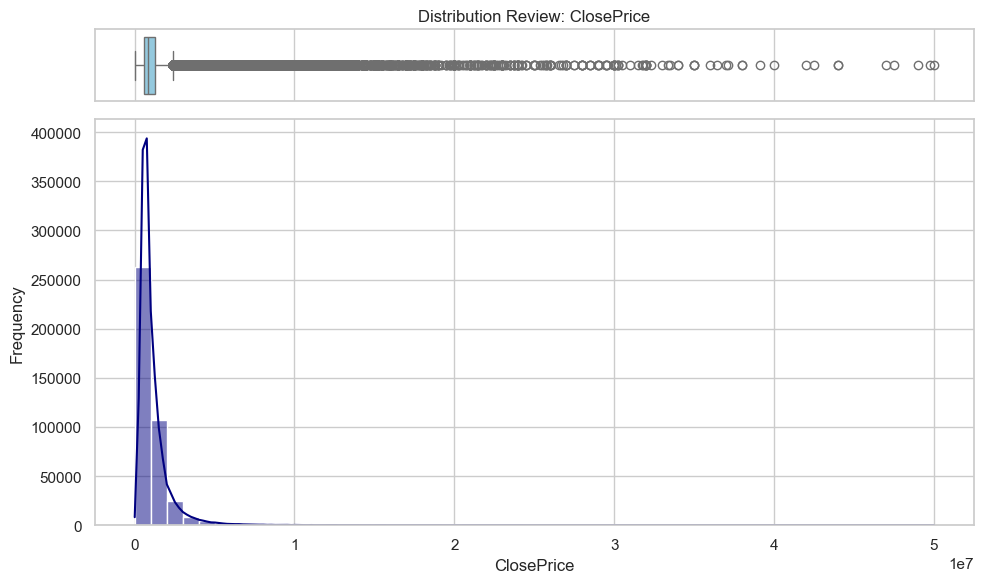

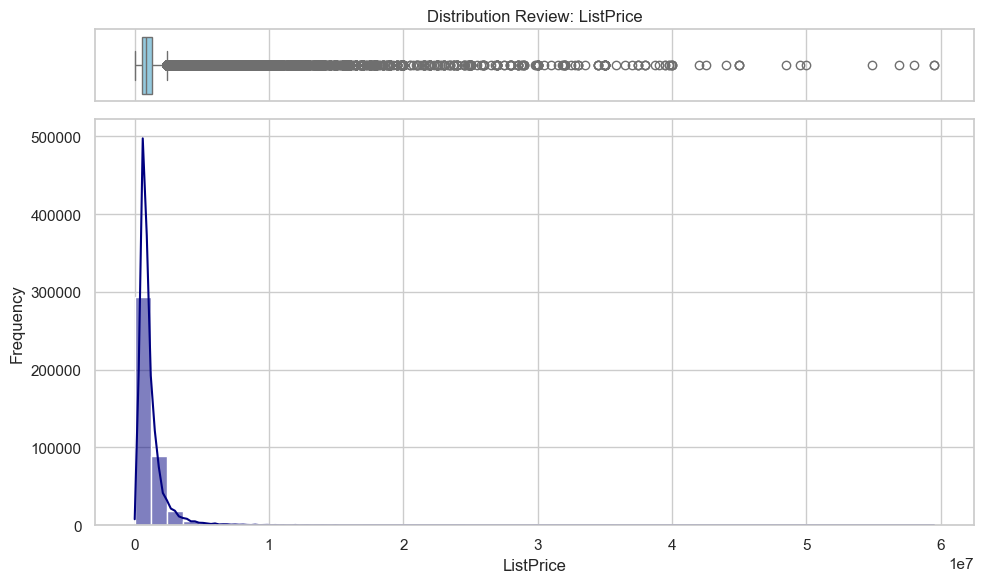

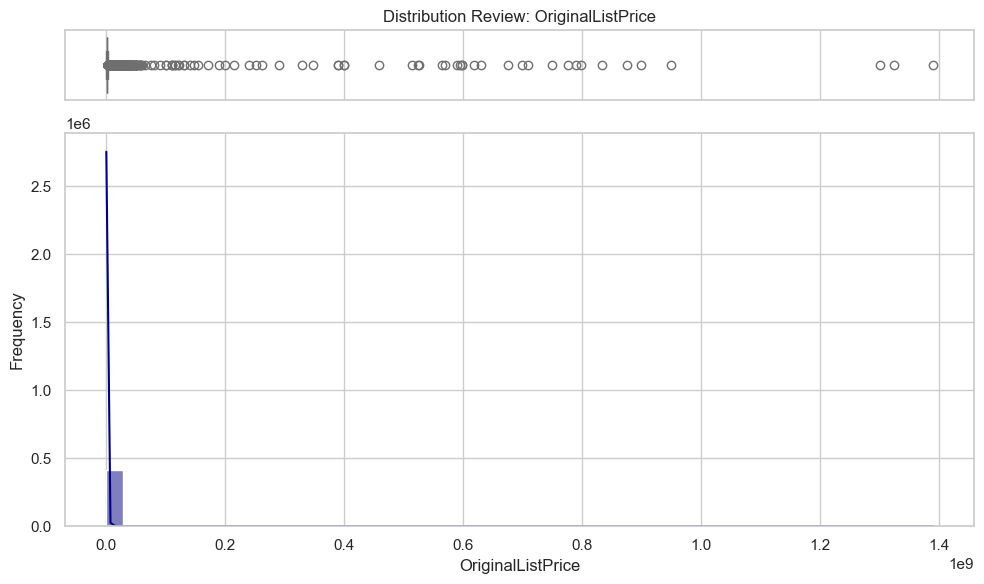

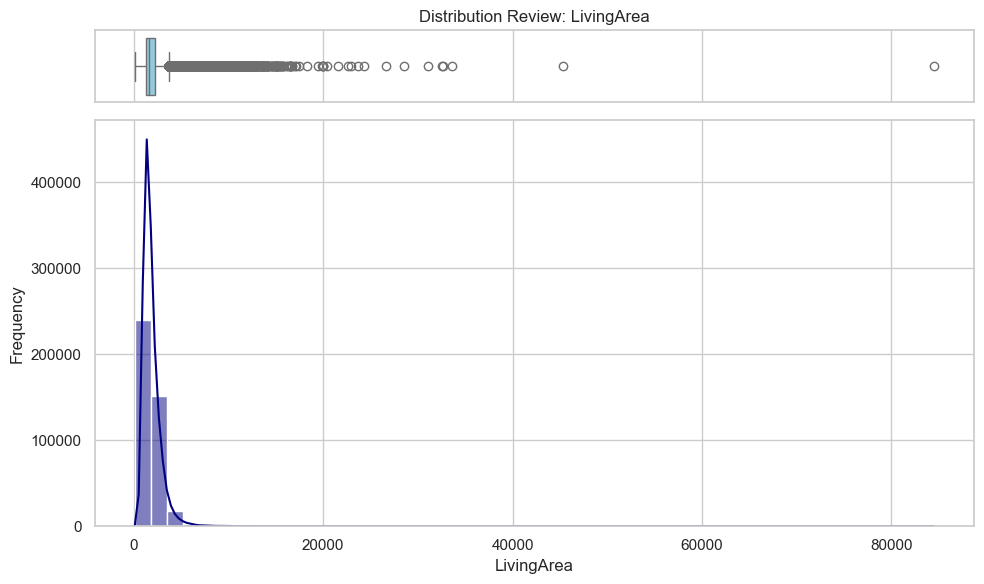

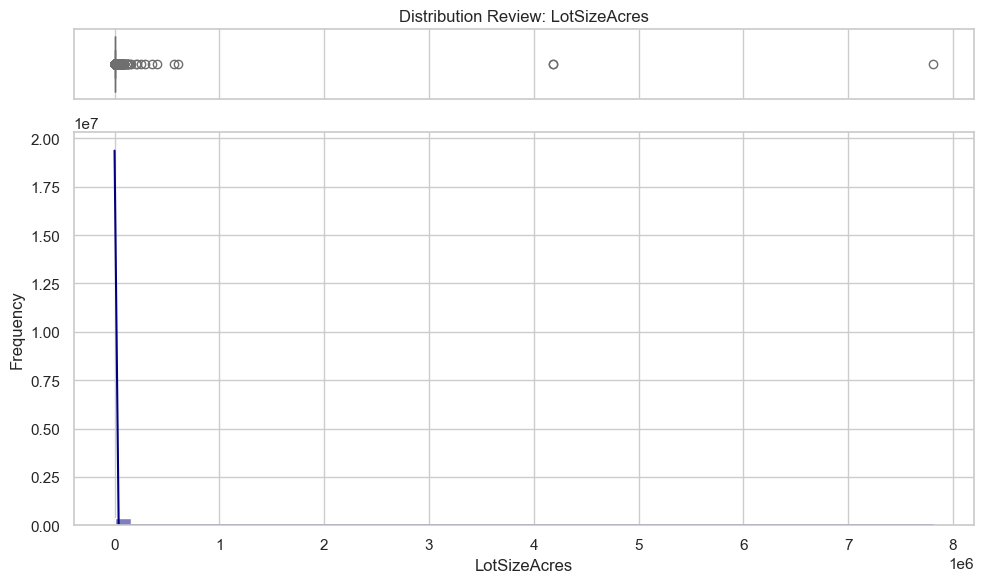

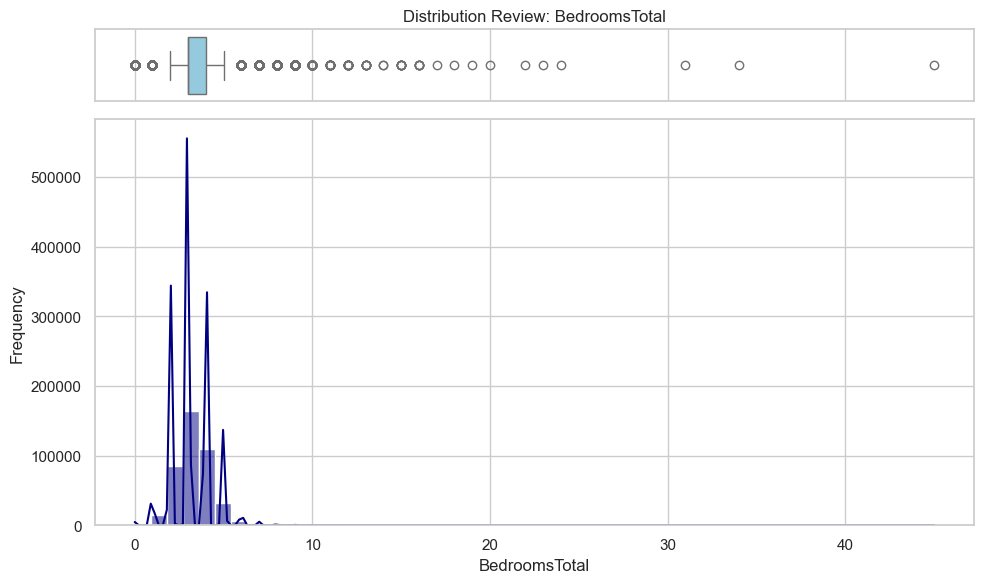

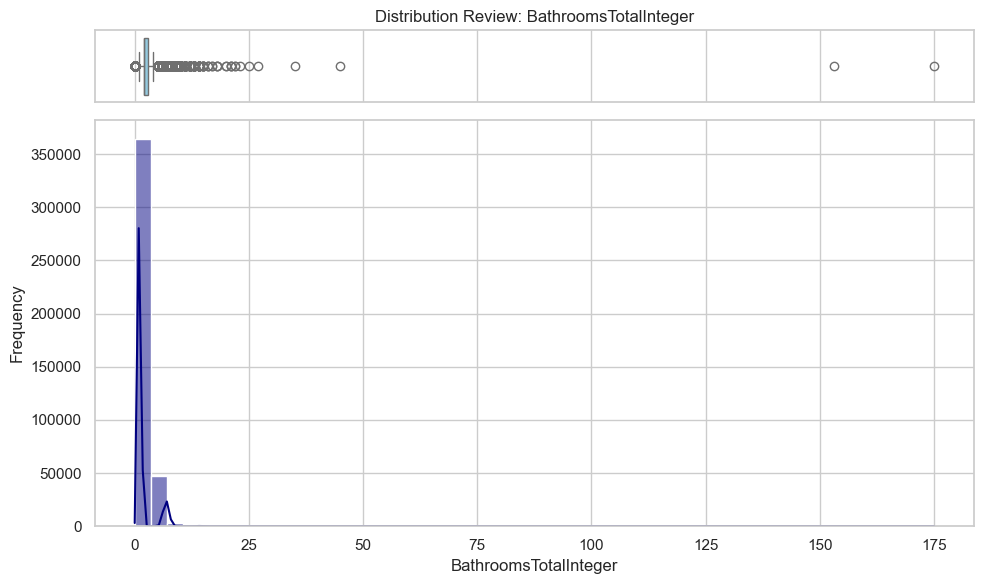

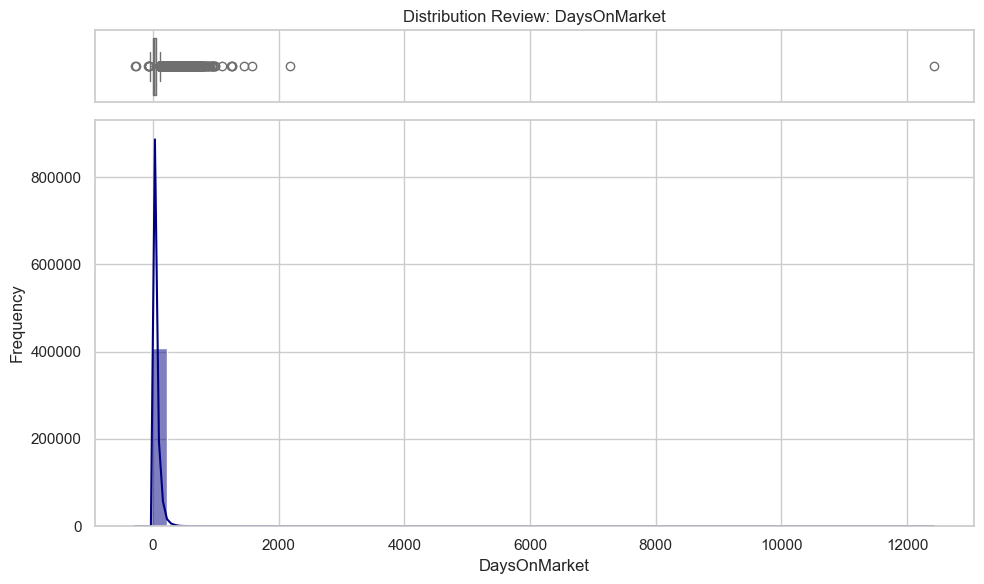

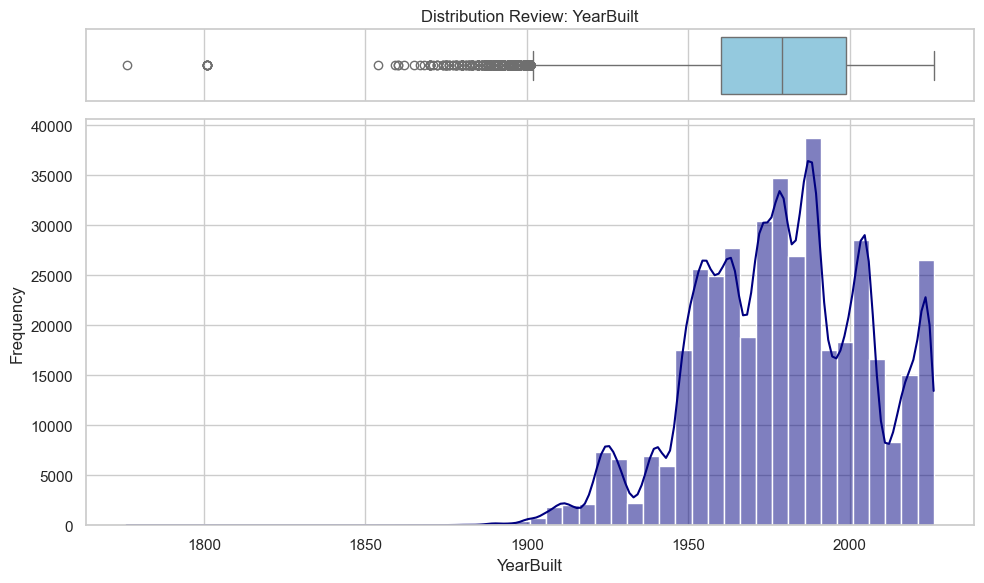


--- Outlier Detection Report (IQR Method) ---
ClosePrice: Found 13108 potential outliers (Outside -1600000.00- 3475000.00)
ListPrice: Found 13630 potential outliers (Outside -1577031.00- 3449023.25)
OriginalListPrice: Found 14404 potential outliers (Outside -1557000.00- 3441000.00)
LivingArea: Found 4605 potential outliers (Outside -1665.00- 5132.00)
LotSizeAcres: Found 47711 potential outliers (Outside -0.34- 0.73)
BedroomsTotal: Found 647 potential outliers (Outside 0.00- 7.00)
BathroomsTotalInteger: Found 2808 potential outliers (Outside -1.00- 6.00)
DaysOnMarket: Found 10813 potential outliers (Outside -112.00- 168.00)
YearBuilt: Found 8 potential outliers (Outside 1843.00- 2116.00)


In [15]:
# 1. Define the list of key numeric fields for analysis
numeric_fields = [
    'ClosePrice', 'ListPrice', 'OriginalListPrice', 'LivingArea', 
    'LotSizeAcres', 'BedroomsTotal', 'BathroomsTotalInteger', 
    'DaysOnMarket', 'YearBuilt'
]

# Ensure only existing columns are processed
available_fields = [col for col in numeric_fields if col in df_sold.columns]

# 2. Generate Percentile Summaries
# Including extreme percentiles (1% and 99%) to help identify outliers
print("--- Numeric Distribution Summary (Percentiles) ---")
distribution_summary = df_sold[available_fields].describe(
    percentiles=[0.01, 0.25, 0.5, 0.75, 0.9, 0.99]
)
print("--- Numeric Distribution Summary (Original Data) ---")
display(distribution_summary.apply(lambda s: s.apply('{0:.2f}'.format)))

#drop outliers
df_plot = df_sold.copy()
if 'ClosePrice' in df_plot.columns:
    df_plot = df_plot[df_plot['ClosePrice'] < 50_000_000] 
    
if 'LivingArea' in df_plot.columns:
    df_plot = df_plot[df_plot['LivingArea'] < 100_000]

# 3. Visualization: Histograms and Boxplots
print("\n--- Generating Distribution Plots ---")
sns.set_theme(style="whitegrid")

for col in available_fields:
    # Drop NaNs for the specific column to avoid plotting errors
    plot_data = df_plot[col].dropna()
    
    # Create a figure with two subplots: Boxplot (top) and Histogram (bottom)
    # This layout is the industry standard for identifying outliers vs density
    f, (ax_box, ax_hist) = plt.subplots(
        2, sharex=True, 
        gridspec_kw={"height_ratios": (.15, .85)}, 
        figsize=(10, 6)
    )
    
    # Top plot: Boxplot to highlight extreme outliers (points beyond whiskers)
    sns.boxplot(x=plot_data, ax=ax_box, color='skyblue')
    ax_box.set(xlabel='', title=f'Distribution Review: {col}')
    
    # Bottom plot: Histogram with KDE to show data skewness
    sns.histplot(data = plot_data, bins=50, kde=True, ax=ax_hist, color='navy')
    ax_hist.set(ylabel='Frequency')
    
    plt.tight_layout()
    plt.show()

# 4. Outlier Identification (Interquartile Range Method)
print("\n--- Outlier Detection Report (IQR Method) ---")
for col in available_fields:
    Q1 = df_sold[col].quantile(0.25)
    Q3 = df_sold[col].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for extreme outliers
    lower_bound = Q1 - 3 * IQR
    upper_bound = Q3 + 3 * IQR
    
    outliers = df_sold[(df_sold[col] < lower_bound) | (df_sold[col] > upper_bound)]
    print(f"{col}: Found {len(outliers)} potential outliers (Outside {lower_bound:.2f}- {upper_bound:.2f})")

### Data Quality Insight: Numeric Distribution & Extreme Outlier Analysis (Week 2)

## 1. Objective
The primary goal of this analysis is to identify and quantify extreme outliers within the **IDX Real Estate Dataset**. By isolating these anomalies, we ensure that subsequent market trend analysis and Tableau visualizations remain accurate and are not skewed by data entry errors or non-representative luxury properties.

---

## 2. Methodology
We utilized the **Interquartile Range (IQR) Method** with a **3x multiplier** (Tukey's Fences) to identify "Extreme Outliers."
- **Calculations**:
    - $IQR = Q3 - Q1$
    - $Lower\ Bound = Q1 - 3 \times IQR$
    - $Upper\ Bound = Q3 + 3 \times IQR$
- **Rationale**: A 3x multiplier is more robust for real estate data than the standard 1.5x, focusing specifically on high-impact anomalies (e.g., $800M+ pricing errors) while preserving legitimate high-end market data where possible.

---

## 3. Statistical Summary Table (3x IQR Results)

| Feature | Outlier Count | Lower Bound | Upper Bound | Status |
| :--- | :--- | :--- | :--- | :--- |
| **ClosePrice** | 9,101 | -$2,974,000.00 | **$4,068,000.00** | Extreme errors detected |
| **ListPrice** | 9,366 | -$2,935,000.00 | $4,030,000.00 | Consistent with ClosePrice |
| **LivingArea** | 7,332 | -1,724.00 sqft | **5,052.00 sqft** | Estates/Mansions flagged |
| **LotSizeAcres**| 69,702 | -0.42 acres | 0.84 acres | Highly right-skewed |
| **YearBuilt** | **21** | 1843.00 | **2116.00** | **Critical Logic Error** |
| **DaysOnMarket**| 16,360 | -126.00 days | 189.00 days | Identifies stale listings |

---

## 4. Key Findings & Insights

### A. Chronological Anomalies (`YearBuilt`)
- **Finding**: 21 records show a `YearBuilt` reaching as far as **2116**.
- **Impact**: These "future" dates will invalidate time-series trends and age-based depreciation models.
- **Action**: These rows must be dropped or corrected to the current year if they represent new construction.

### B. Pricing Distribution Skewness
- **Finding**: The mathematical lower bound for `ClosePrice` is negative (-$2.97M), while the upper bound is ~$4.07M.
- **Insight**: This confirms a heavy **Right-Skewed** distribution. Previously identified data points (e.g., $750M+) are confirmed as extreme statistical noise far beyond the $4M threshold.
- **Action**: Implement **Capping (Winsorization)** at the $4.07M mark for aggregate reporting to stabilize mean values.

### C. Land Size Sensitivity (`LotSizeAcres`)
- **Finding**: Nearly 70,000 records are flagged as outliers due to a low upper bound of 0.84 acres.
- **Insight**: The dataset is heavily concentrated in urban/suburban residential properties. Large rural lots are treated as anomalies by the global model, suggesting a need for market segmentation.

---

## 5. Proposed Handling Strategy

1.  **Data Scrubbing**: Permanently drop records where `YearBuilt > 2026`.
2.  **Statistical Capping**: Apply `.clip()` to `ClosePrice` and `ListPrice` using the 3x IQR upper bounds to mitigate the influence of "monster" outliers on KPIs.
3.  **Market Segmentation**: For `LotSizeAcres`, consider bifurcating the analysis into "Standard Residential" (< 1 acre) and "Acreage/Ranch" (> 1 acre) to better account for variance.


--- Property Type Share ---
PropertyType
Residential    100.0
Name: proportion, dtype: float64

--- Price Metrics ---
Average: $1,188,025.34
Median: $822,500.00


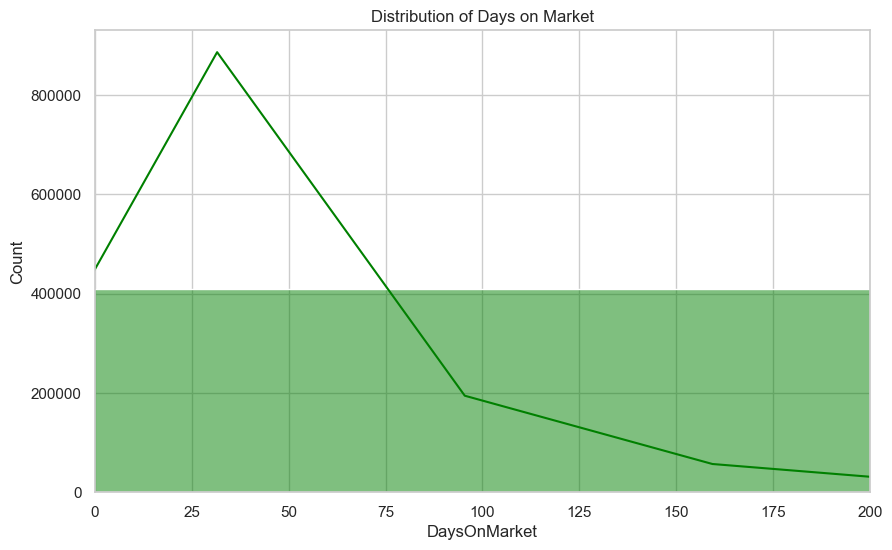


--- Price Strategy Analysis ---
Sold Above List: 40.12%
Sold Below List: 42.53%
Sold At List: 17.35%

--- Data Integrity Check ---
Number of records with CloseDate before ListingDate: 61

--- Top 5 Counties by Median Price ---
CountyOrParish
Del Norte        2485000.0
San Mateo        1700000.0
Santa Clara      1600000.0
Santa Cruz       1200000.0
San Francisco    1198000.0
Name: ClosePrice, dtype: float64


In [16]:
# 1. Residential vs. Other Property Type Share
print("--- Property Type Share ---")
prop_share = df_sold['PropertyType'].value_counts(normalize=True) * 100
print(prop_share)

# 2. Median and Average Close Prices
avg_price = df_sold['ClosePrice'].mean()
med_price = df_sold['ClosePrice'].median()
print(f"\n--- Price Metrics ---\nAverage: ${avg_price:,.2f}\nMedian: ${med_price:,.2f}")

# 3. Days on Market (DOM) Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df_sold['DaysOnMarket'].dropna(), bins=50, kde=True, color='green')
plt.title('Distribution of Days on Market')
plt.xlim(0, 200) # Zoom in to see the bulk of data
plt.show()

# 4. Sold Above vs. Below List Price
# Logic: Comparison between ClosePrice and ListPrice
df_sold['PriceDiff'] = df_sold['ClosePrice'] - df_sold['ListPrice']
above_list = (df_sold['PriceDiff'] > 0).mean() * 100
below_list = (df_sold['PriceDiff'] < 0).mean() * 100
at_list = (df_sold['PriceDiff'] == 0).mean() * 100

print(f"\n--- Price Strategy Analysis ---")
print(f"Sold Above List: {above_list:.2f}%")
print(f"Sold Below List: {below_list:.2f}%")
print(f"Sold At List: {at_list:.2f}%")

# 5. Date Consistency Issues
# Check if CloseDate is earlier than ListingContractDate
date_errors = df_sold[df_sold['CloseDate'] < df_sold['ListingContractDate']]
print(f"\n--- Data Integrity Check ---")
print(f"Number of records with CloseDate before ListingDate: {len(date_errors)}")

# 6. Counties with the Highest Median Prices
print(f"\n--- Top 5 Counties by Median Price ---")
# Use CountyOrParish (Standard MLS field name)
county_prices = df_sold.groupby('CountyOrParish')['ClosePrice'].median().sort_values(ascending=False)
print(county_prices.head(5))

In [17]:
print("Fetching FRED Mortgage Rates...")

#preview
df_sold = df_sold.drop(columns=[c for c in df_sold.columns if c.endswith('.1')], errors='ignore')
df_listed = df_listed.drop(columns=[c for c in df_listed.columns if c.endswith('.1')], errors='ignore')


# Step 1 – Fetch the mortgage rate data from FRED 
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=MORTGAGE30US" 
mortgage = pd.read_csv(url, parse_dates=['observation_date']) 
mortgage.columns = ['date', 'rate_30yr_fixed'] 

# Step 2 – Resample weekly rates to monthly averages 
mortgage['year_month'] = mortgage['date'].dt.to_period('M').astype(str) 
mortgage_monthly = ( 
    mortgage.groupby('year_month')['rate_30yr_fixed'] 
    .mean() 
    .reset_index() 
) 

# Step 3 – Create a matching year_month key on the MLS datasets 
df_sold['CloseDate'] = pd.to_datetime(df_sold['CloseDate'], errors='coerce')
df_sold['year_month'] = df_sold['CloseDate'].dt.to_period('M').astype(str) 

df_listed['ListingContractDate'] = pd.to_datetime(df_listed['ListingContractDate'], errors='coerce')
df_listed['year_month'] = df_listed['ListingContractDate'].dt.to_period('M').astype(str) 

# Step 4 – Merge 
# Safeguard: drop existing rate column if it exists to prevent 'rate_30yr_fixed_x'
if 'rate_30yr_fixed' in df_sold.columns: df_sold.drop(columns=['rate_30yr_fixed'], inplace=True)
if 'rate_30yr_fixed' in df_listed.columns: df_listed.drop(columns=['rate_30yr_fixed'], inplace=True)

sold_with_rates = df_sold.merge(mortgage_monthly, on='year_month', how='left') 
listings_with_rates = df_listed.merge(mortgage_monthly, on='year_month', how='left') 

# Step 5 – Validate the merge 
print("Sold Data Null Rates:", sold_with_rates['rate_30yr_fixed'].isnull().sum()) 
print("Listed Data Null Rates:", listings_with_rates['rate_30yr_fixed'].isnull().sum()) 

# Preview 
print( 
    sold_with_rates[ 
        ['CloseDate', 'year_month', 'ClosePrice', 'rate_30yr_fixed'] 
    ].head() 
)

# Export for the next phase
sold_with_rates.to_csv('Week3_Enriched_Sold.csv', index=False)
listings_with_rates.to_csv('Week3_Enriched_Listed.csv', index=False)

print("\n Enriched datasets have been saved.")

Fetching FRED Mortgage Rates...
Sold Data Null Rates: 0
Listed Data Null Rates: 0
   CloseDate year_month  ClosePrice  rate_30yr_fixed
0 2024-01-26    2024-01    240000.0           6.6425
1 2024-01-05    2024-01    815000.0           6.6425
2 2024-01-05    2024-01    810000.0           6.6425
3 2024-01-30    2024-01    858000.0           6.6425
4 2024-01-29    2024-01   1890500.0           6.6425

 Enriched datasets have been saved.


In [18]:
# Tableau file
listings_with_rates.to_csv('Week3_Enriched_Listed.csv', index=False, encoding='utf-8-sig')
print("✅ Week3_Enriched_Listed.csv exported successfully.")

sold_with_rates.to_csv('Week3_Enriched_Sold.csv', index=False, encoding='utf-8-sig')
print("✅ Week3_Enriched_Sold.csv exported successfully.")

✅ Week3_Enriched_Listed.csv exported successfully.
✅ Week3_Enriched_Sold.csv exported successfully.
